In [2]:
!pip install mysql-connector-python
!pip install sqlalchemy

In [14]:
import mysql.connector
import pandas as pd

In [ ]:
conn = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "504103",
    database = "batch5"
)

In [16]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///students.db")

In [17]:
print("Cleaned data successfully exported to MySQL!")

Cleaned data successfully exported to MySQL!


In [18]:
query = " SELECT * FROM student_data";
df = pd.read_sql(query,conn)
df.head()

C:\Users\Navaneeth\AppData\Local\Temp\ipykernel_12252\929160185.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [19]:
df.info() #->>>> getting the information 
df.isnull().sum() #->>> checke the missing values 
df.describe() #--> we get here everything like(Mean,median...)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


In [20]:
df = df.drop_duplicates()

In [21]:
df.isnull().sum()

Gender                                   0
Age                                      0
Academic Pressure                        0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.isnull().sum()

Gender                                   0
Age                                      0
Academic Pressure                        0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [25]:
df['Sleep Duration'] = df['Sleep Duration'].str.strip()

In [26]:
df['Sleep Duration'] = df['Sleep Duration'].map({
    'Less than 5 hours': 4,
    '5-6 hours': 5.5,
    '7-8 hours': 7.5,
    'More than 8 hours': 9
})

In [27]:
df['Sleep Duration'] = df['Sleep Duration'].astype(float)

In [28]:
df["Sleep Duration"] 

0      7.5
1      5.5
2      5.5
3      9.0
4      9.0
      ... 
497    9.0
498    4.0
499    5.5
500    9.0
501    9.0
Name: Sleep Duration, Length: 502, dtype: float64

In [29]:
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7.5,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5.5,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5.5,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,9.0,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,9.0,Healthy,Yes,4,2,Yes,No


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    float64
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [31]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [32]:
df = df[(df['Age'] > 15 ) | (df['Age']<35)]

<H1>Exploratory Data Analysis<H1>

In [33]:
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7.5,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5.5,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5.5,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,9.0,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,9.0,Healthy,Yes,4,2,Yes,No


**What is the distribution of academic pressure among students?**

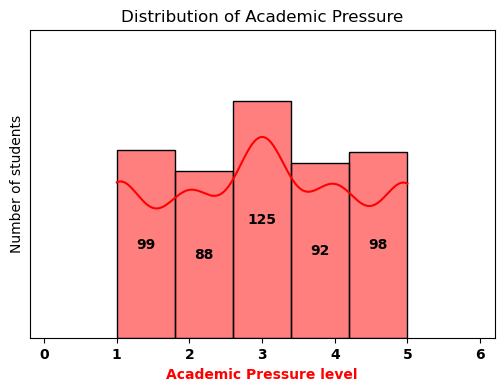

In [42]:
plt.figure(figsize=(6,4))
c=sns.histplot(df['Academic Pressure'],bins=5,kde=True,color='RED')
plt.title("Distribution of Academic Pressure")
plt.xlabel("Academic Pressure level",fontweight='bold',color="red")
plt.ylabel("Number of students")
for i in c.containers:
    c.bar_label(i,fontweight='bold',label_type='center')
plt.yticks([])
for i in c.get_xticklabels():
    i.set_fontweight("bold")
c.margins(0.3)
plt.show()

**2. Distribution: Sleep Duration**

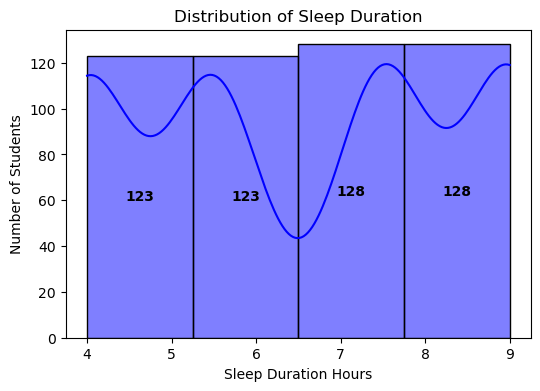

In [41]:
plt.figure(figsize=(6,4))
c=sns.histplot(df['Sleep Duration'],bins=4,color="Blue",kde=True,alpha=0.5)
for i in c.containers:
    c.bar_label(i,fontweight='bold',label_type='center')
plt.title("Distribution of Sleep Duration")
plt.xlabel("Sleep Duration Hours")
plt.ylabel("Number of Students")
plt.show()

**Box Plot: Study Hours vs Depression**

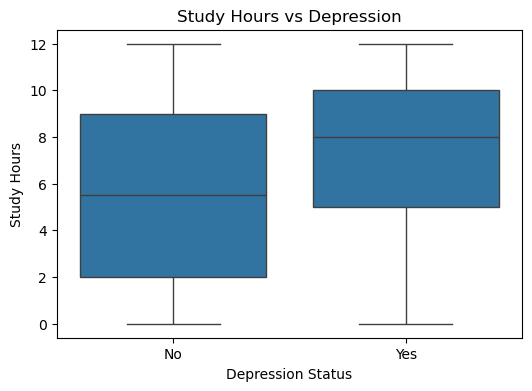

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Depression', y='Study Hours', data=df)
plt.title("Study Hours vs Depression")
plt.xlabel("Depression Status")
plt.ylabel("Study Hours")
plt.show()

In [37]:
pd.crosstab(df['Academic Pressure'], df['Depression'])

Depression,No,Yes
Academic Pressure,,
1.0,82,17
2.0,61,27
3.0,62,63
4.0,30,62
5.0,15,83


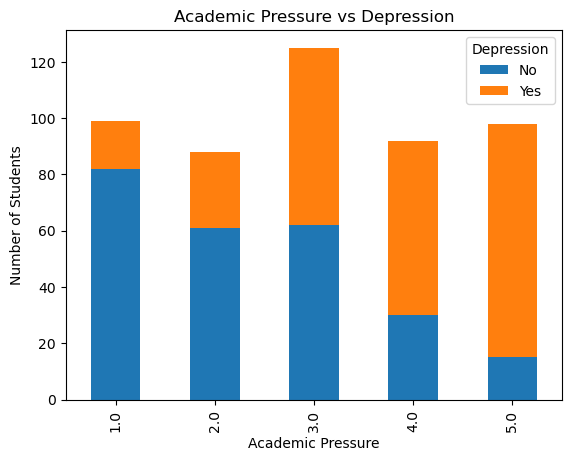

In [38]:
pd.crosstab(df['Academic Pressure'], df['Depression']).plot(kind='bar', stacked=True)
plt.title("Academic Pressure vs Depression")
plt.xlabel("Academic Pressure")
plt.ylabel("Number of Students")
plt.show()

In [39]:
df.to_excel("student_data_cleaned.xlsx", index=False)

**3.Correlation Matrix**

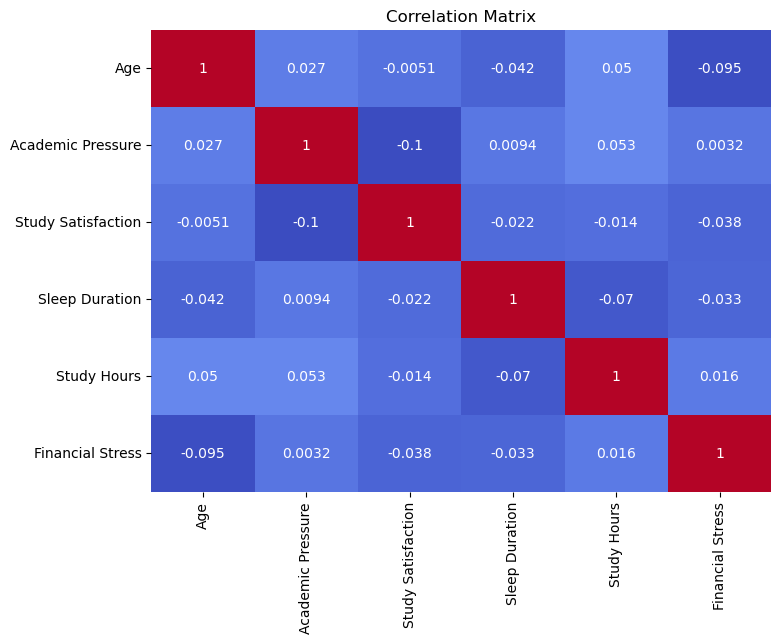

In [40]:
plt.figure(figsize=(8,6))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True, cmap="coolwarm",cbar=False)
plt.title("Correlation Matrix")
plt.show()